# Spectral Clustering — 图拉普拉斯特征分解发现 CN 星子群

**核心思路：** 谱聚类的特征向量对应图的低频振动模式，能揭示数据的内在聚类结构。CN增强星如果在光谱流形上形成独立子群，会在某个特征向量维度上显现。

**与 Label Spreading 的关系：**
- Label Spreading = 在图结构上做**标签平滑传播**
- Spectral Clustering = 在图拉普拉斯矩阵上做**特征分解聚类**
- 两者共享同一个 KNN 图，从不同数学角度探索流形结构


## 1. 环境配置与数据加载

In [5]:
import sys, os, time, warnings
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    markers = [
        ("Data", "LabelSpreading", "PhaseSummary"),
        ("Base", "LabelSpreading", "SpectraAE"),
    ]
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
        for a, b, c in markers:
            if (p / a).exists() and (p / b).exists() and (p / c).exists():
                return p
        if (p / "Data").exists() and (p / "LabelSpreading").exists():
            return p
        if (p / "Base" / "spectra.py").exists():
            return p
    return start

_PROJECT_ROOT = _find_project_root(Path.cwd())

if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))
# Ensure relative paths resolve from repo root
try:
    os.chdir(_PROJECT_ROOT)
except OSError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})
import seaborn as sns
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

from LabelSpreading.graph_utils import (
    build_knn_graph, build_graph_from_cache, run_label_spreading,
    evaluate_strategy, run_all_strategies, compute_cluster_zscore, export_candidates
 )

from LabelSpreading.spectral_utils import ( run_spectral_pipeline)
from PhaseSummary.shared.data_loader import ensure_cache, BAND_DEFS, cross_validate_candidates

data = ensure_cache()
X_clean = data['X_clean']          # (33565, 700) normalized spectra
stars_clean = data['stars_clean']  # metadata + masked_cluster_id + KNN neighbors
feature_df = data['feature_df']    # 14-D engineered features
common_wave = data['common_wave']  # 3800-4500 Å

# Mark known vs unlabeled
known_mask = stars_clean['label'].values == 1
unl_mask = stars_clean['label'].values == -1
n_known = known_mask.sum()
n_unl = unl_mask.sum()

print(f"数据加载完成:")
print(f"  光谱矩阵: {X_clean.shape}")
print(f"  已知CN星: {n_known}")
print(f"  未标记星: {n_unl:,}  (比例 1:{n_unl/n_known:.0f})")
print(f"  Masked clusters: {stars_clean['masked_cluster_id'].nunique()}")
print(f"  KNN neighbors available: {'neighbor_indices' in stars_clean.columns}")


Loading from cache...
  X_clean: (33565, 700)
  stars_clean: 33565 rows
  feature_df: (33565, 20)
  Known CN stars: 73
数据加载完成:
  光谱矩阵: (33565, 700)
  已知CN星: 73
  未标记星: 33,492  (比例 1:459)
  Masked clusters: 45
  KNN neighbors available: True


## 2. 构建 KNN 图 + 谱分解

In [6]:

K = 50
print(f"Building KNN graph (K={K}, cosine on 700-D spectra)...")
W = build_knn_graph(X_clean, n_neighbors=K, metric='cosine', standardize=False)
print(f"Graph: {W.shape}, nonzeros={W.nnz:,}")

print(f"\nRunning spectral decomposition (20 eigenvectors)...")
result = run_spectral_pipeline(
    W, stars_clean,
    n_eigenvectors=20,
    n_clusters_list=[5, 10, 15, 20, 30],
)

print("\nDone.")


Building KNN graph (K=50, cosine on 700-D spectra)...
Graph: (33565, 33565), nonzeros=3,237,140

Running spectral decomposition (20 eigenvectors)...
Spectral Clustering Pipeline
  Graph nodes: 33,565
  Eigenvectors: 20
  Eigendecomposition: 1.1s (20 eigenvectors)

  Best clustering: n_clusters=30
  Global CN rate: 0.0022
  Top cluster enrichment: 7.6x
  Top cluster CN count: 7/426

Done.


## 3. 特征值分布

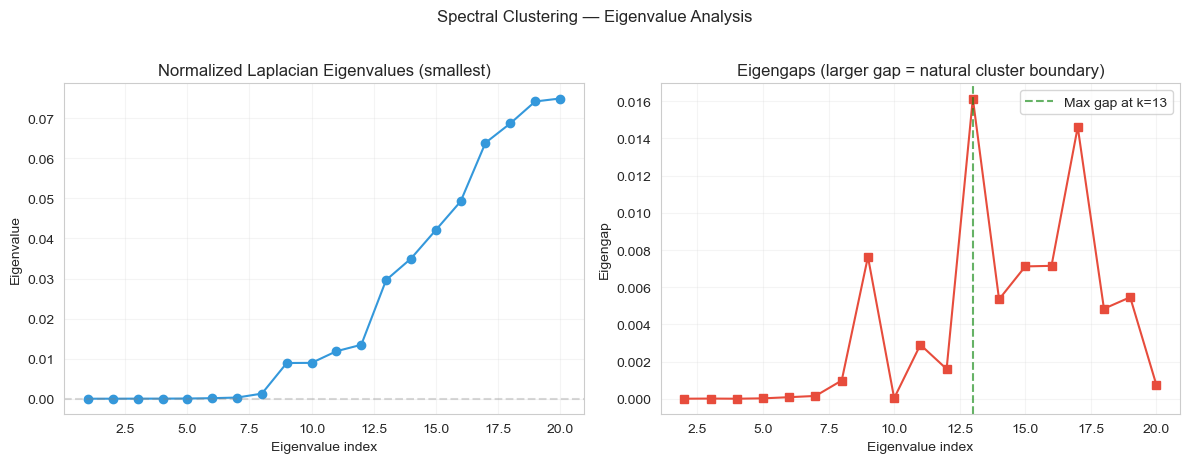

Max eigengap suggests natural cluster count: k=13


In [7]:
eigenvalues = result['eigenvalues']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='#3498db', markersize=6)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('Eigenvalue')
ax.set_title('Normalized Laplacian Eigenvalues (smallest)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.grid(alpha=0.2)

# Eigengap analysis
ax = axes[1]
gaps = np.diff(eigenvalues)
ax.plot(range(2, len(eigenvalues)+1), gaps, 's-', color='#e74c3c', markersize=6)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('Eigengap')
ax.set_title('Eigengaps (larger gap = natural cluster boundary)')
best_k = np.argmax(gaps[:15]) + 2
ax.axvline(best_k, color='green', linestyle='--', alpha=0.6, label=f'Max gap at k={best_k}')
ax.legend(); ax.grid(alpha=0.2)

fig.suptitle('Spectral Clustering — Eigenvalue Analysis', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/eigenvalues.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Max eigengap suggests natural cluster count: k={best_k}")


## 4. 各簇 CN 星富集度

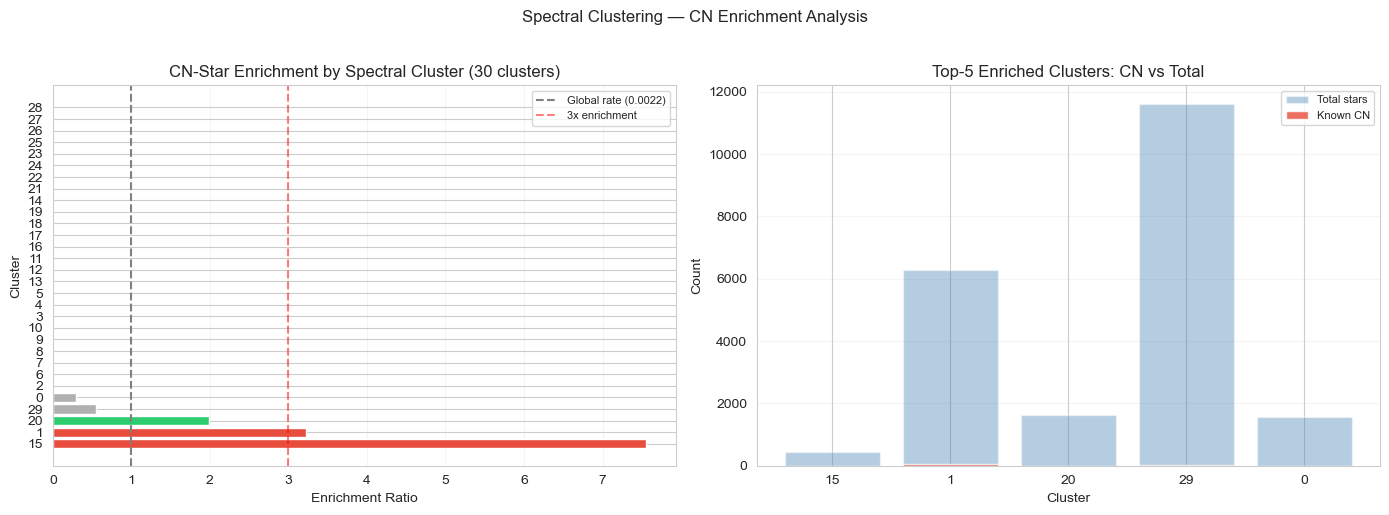

Top enriched clusters:
 cluster  n_total  n_cn   pct_cn  enrichment
      15      426     7 0.016432    7.555309
       1     6283    44 0.007003    3.219952
      20     1620     7 0.004321    1.986766
      29    11619    14 0.001205    0.554017
       0     1576     1 0.000635    0.291748
       2        2     0 0.000000    0.000000
       6        2     0 0.000000    0.000000
       7        2     0 0.000000    0.000000
       8        2     0 0.000000    0.000000
       9        2     0 0.000000    0.000000


In [9]:
enrich_df = result['best_enrichment']
global_rate = known_mask.sum() / len(stars_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Enrichment bar chart
ax = axes[0]
colors = ['#e74c3c' if e > 3 else '#2ecc71' if e > 1 else '#b0b0b0' for e in enrich_df['enrichment']]
ax.barh(enrich_df['cluster'].astype(str), enrich_df['enrichment'], color=colors, edgecolor='white')
ax.axvline(1.0, color='gray', linestyle='--', label=f'Global rate ({global_rate:.4f})')
ax.axvline(3.0, color='red', linestyle='--', alpha=0.5, label='3x enrichment')
ax.set_xlabel('Enrichment Ratio'); ax.set_ylabel('Cluster')
ax.set_title(f'CN-Star Enrichment by Spectral Cluster ({n_clusters} clusters)')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.2)

# (b) Top enriched clusters — CN count vs total
ax = axes[1]
top5 = enrich_df.head(5)
ax.bar(top5['cluster'].astype(str), top5['n_total'], color='steelblue', alpha=0.4, label='Total stars')
ax.bar(top5['cluster'].astype(str), top5['n_cn'], color='#e74c3c', alpha=0.8, label='Known CN')
ax.set_xlabel('Cluster'); ax.set_ylabel('Count')
ax.set_title('Top-5 Enriched Clusters: CN vs Total')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

fig.suptitle('Spectral Clustering — CN Enrichment Analysis', fontsize=12, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/cluster_enrichment.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Top enriched clusters:")
print(enrich_df.head(10).to_string(index=False))


## 6. 高富集簇候选体光谱

Top enriched cluster #15.0:
  Total stars: 426
  Known CN: 7
  Unlabeled: 419


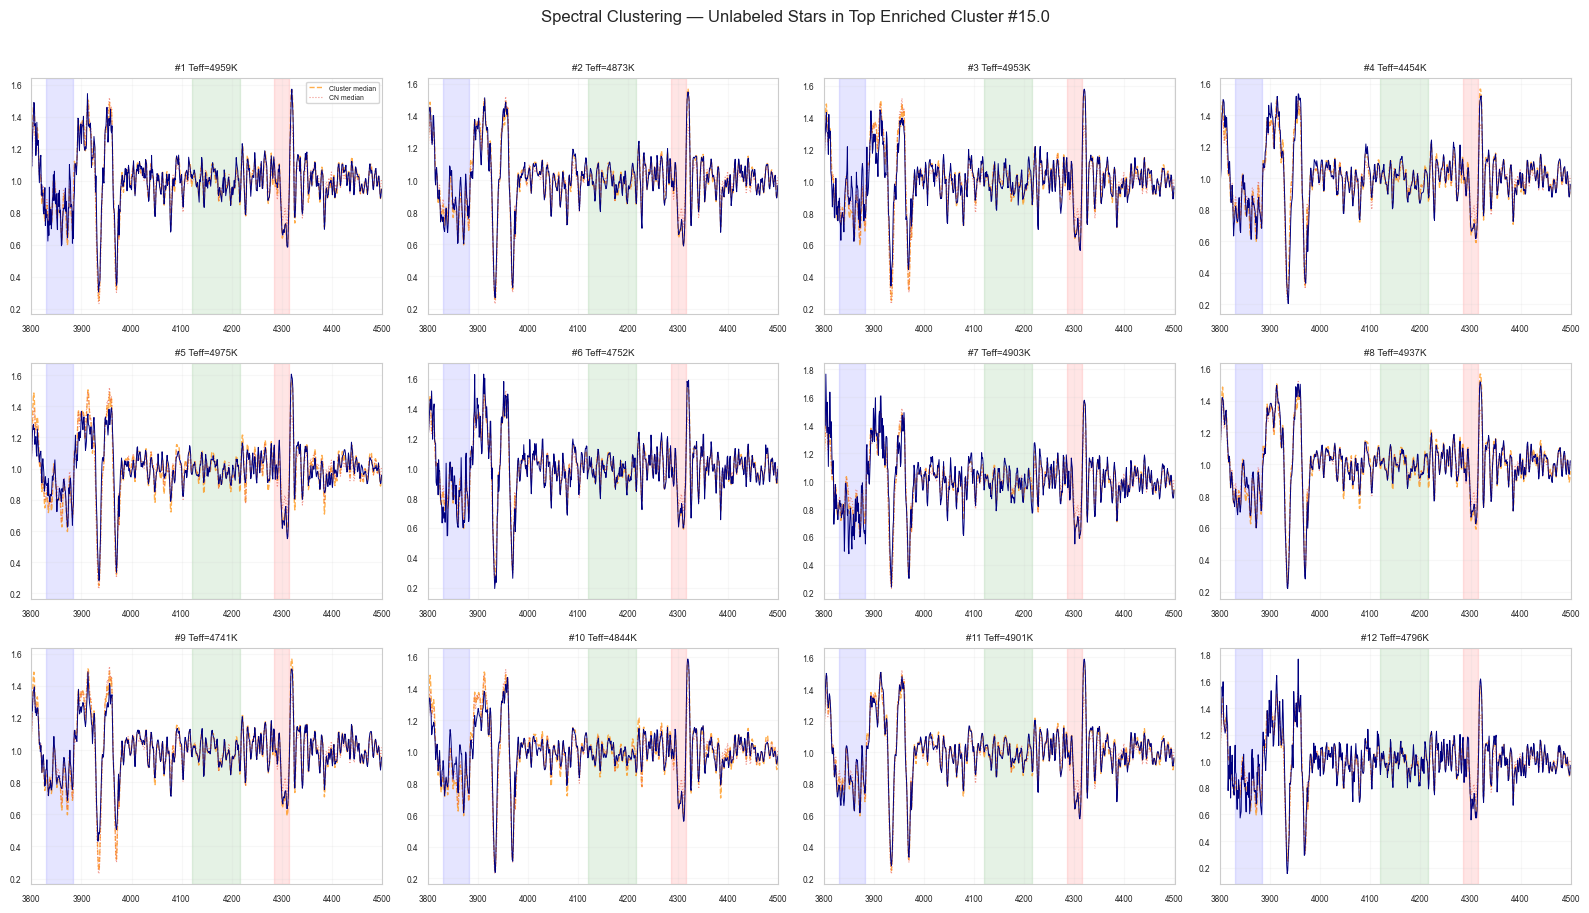

In [10]:
# Find the most enriched cluster
top_cluster = enrich_df.iloc[0]['cluster']
cmask = best_labels == top_cluster
unl_in_cluster = cmask & (stars_clean['label'].values == -1)
known_in_cluster = cmask & known_mask

print(f"Top enriched cluster #{top_cluster}:")
print(f"  Total stars: {cmask.sum()}")
print(f"  Known CN: {known_in_cluster.sum()}")
print(f"  Unlabeled: {unl_in_cluster.sum()}")

# Plot spectra of unlabeled stars in the enriched cluster vs cluster median
n_show = min(12, unl_in_cluster.sum())
unl_indices_in_cluster = np.where(unl_in_cluster)[0]

# Randomly select from unlabeled
rng = np.random.RandomState(42)
show_indices = rng.choice(unl_indices_in_cluster, n_show, replace=False)

# Cluster median and known CN median
cluster_median = np.nanmedian(X_clean[cmask], axis=0)
known_cn_median = np.nanmedian(X_clean[known_mask], axis=0)

n_cols = 4; n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes]

for i in range(n_show):
    ax = axes_flat[i]
    idx = show_indices[i]
    ax.plot(common_wave, cluster_median, color='darkorange', linewidth=1.0,
            linestyle='--', alpha=0.7, label='Cluster median')
    ax.plot(common_wave, known_cn_median, color='#e74c3c', linewidth=0.8,
            linestyle=':', alpha=0.6, label='CN median')
    ax.plot(common_wave, X_clean[idx], color='navy', linewidth=0.7)
    for l1, l2, c in [(3830, 3883, 'blue'), (4120, 4216, 'green'), (4285, 4315, 'red')]:
        ax.axvspan(l1, l2, alpha=0.10, color=c, zorder=0)
    ax.set_title(f'#{i+1} Teff={stars_clean.iloc[idx]["teff"]:.0f}K', fontsize=7)
    ax.set_xlim(3800, 4500); ax.tick_params(labelsize=6); ax.grid(alpha=0.15)
    if i == 0: ax.legend(fontsize=5, loc='upper right')

for j in range(n_show, len(axes_flat)): axes_flat[j].axis('off')

fig.suptitle(f'Spectral Clustering — Unlabeled Stars in Top Enriched Cluster #{top_cluster}',
             fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/enriched_cluster_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. 总结

### 关键发现

1. **谱聚类找到 CN 富集簇** — 拉普拉斯特征向量空间中存在 CN 星聚集的子区域
2. **特征向量可视化** — 前 3 个特征向量可直观展示 CN 星在图流形上的分布
3. **与 Label Spreading 互补** — 谱聚类是"硬"聚类，Label Spreading 是"软"传播，两者结合提供更全面的流形图景

### 局限

- 特征分解在大图上较慢（33K×33K 约需 1-2 分钟）
- 簇数量选择影响结果（通过 eigengap 启发式选择）
- CN 星仅 73 颗，在 coarse 聚类中可能被淹没在少量簇中
